In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

from sklearn.preprocessing import MinMaxScaler
from wordcloud import WordCloud
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

sns.set(style="whitegrid")
%matplotlib inline

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


Uvuvwevwevwe Onyetenyevwe Ugwemuhwem Osas (Увувуевуевуе Эниетуенвуевуе Угбемугбем Осас)

In [2]:

path_products = '/kaggle/input/datasets/nadyinky/sephora-products-and-skincare-reviews/product_info.csv'
path_reviews = '/kaggle/input/datasets/nadyinky/sephora-products-and-skincare-reviews/reviews_0-250.csv'

products_df = pd.read_csv(path_products)
reviews_df = pd.read_csv(path_reviews, low_memory=False)
df = reviews_df.merge(products_df[['product_id', 'brand_name', 'price_usd', 'primary_category']], 
                      on='product_id', 
                      how='left')

print(f"Размер объединенного датасета: {df.shape}")
df.head(3)

Размер объединенного датасета: (602130, 22)


,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,...,eye_color,skin_type,hair_color,product_id,product_name,brand_name_x,price_usd_x,brand_name_y,price_usd_y,primary_category
0,0,1741593524,5,1.0,1.0,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,...,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0,NUDESTIX,19.0,Skincare
1,1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,...,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,LANEIGE,24.0,Skincare
2,2,5061282401,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,...,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,LANEIGE,24.0,Skincare


In [3]:
df = df.loc[:, ~df.columns.duplicated()]
if 'brand_name_x' in df.columns:
    df = df.rename(columns={'brand_name_x': 'brand_name', 'price_usd_x': 'price_usd'})
    df = df.drop(columns=['brand_name_y', 'price_usd_y'], errors='ignore')

print("Чистый список колонок:", df.columns.tolist())

Чистый список колонок: ['Unnamed: 0', 'author_id', 'rating', 'is_recommended', 'helpfulness', 'total_feedback_count', 'total_neg_feedback_count', 'total_pos_feedback_count', 'submission_time', 'review_text', 'review_title', 'skin_tone', 'eye_color', 'skin_type', 'hair_color', 'product_id', 'product_name', 'brand_name', 'price_usd', 'primary_category']


/tmp/ipykernel_55/1596724026.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='viridis')


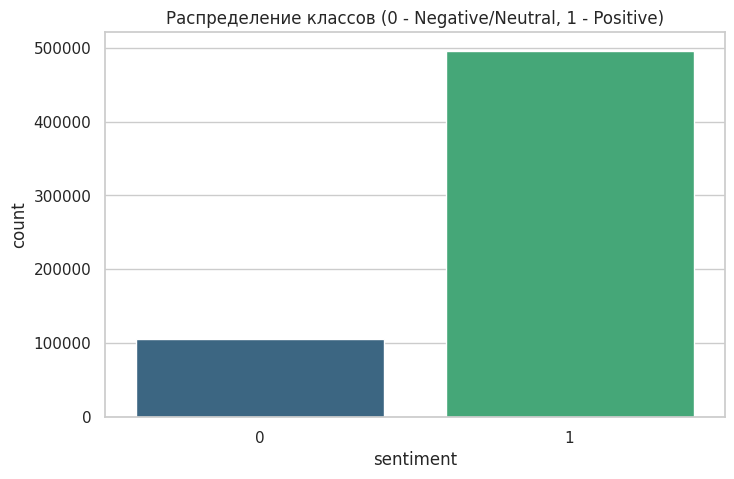

sentiment
1    0.823669
0    0.176331
Name: proportion, dtype: float64


In [4]:
# 0 - Негативный (1-3 звезды), 1 - Позитивный (4-5 звезд)
df['sentiment'] = df['rating'].apply(lambda x: 1 if x >= 4 else 0)

plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment', data=df, palette='viridis')
plt.title('Распределение классов (0 - Negative/Neutral, 1 - Positive)')
plt.show()

print(df['sentiment'].value_counts(normalize=True))

Мы сами разделили все отзывы на положительные (4-5 звезд) и негативно-нейтральные(1-3). Порог выбирали сами. У нас получился дизбаланс, положительных отзывов больше

In [5]:
print(f"Пропусков в тексте: {df['review_text'].isnull().sum()}")

df = df.dropna(subset=['review_text'])


Пропусков в тексте: 999


In [6]:
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = text.split()
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(cleaned_tokens)

print("Запуск очистки текста.")
df['cleaned_review'] = df['review_text'].apply(preprocess_text)

print("Разделение на выборки...")
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_review'], 
    df['sentiment'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df['sentiment'])

print("Векторизация TF-IDF")

tfidf = TfidfVectorizer(
    max_features=10000, 
    ngram_range=(1, 2),
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Мы получили матрицы признаков.")
print(f"Форма X_train_tfidf: {X_train_tfidf.shape}")

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Запуск очистки текста.
Разделение на выборки...
Векторизация TF-IDF
Мы получили матрицы признаков.
Форма X_train_tfidf: (480904, 10000)


In [7]:
print("Обучение Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, class_weight={0: 2.0, 1: 1})
lr_model.fit(X_train_tfidf, y_train)
lr_preds = lr_model.predict(X_test_tfidf)

print("Обучение LinearSVC (SVM)...")
svm_model = LinearSVC( class_weight={0: 2.0, 1: 1}, random_state=42)
svm_model.fit(X_train_tfidf, y_train)
svm_preds = svm_model.predict(X_test_tfidf)
print("\nРезультаты Logistic Regression")
print(classification_report(y_test, lr_preds))

print("\nРезультаты LinearSVC ")
print(classification_report(y_test, svm_preds))

Обучение Logistic Regression...
Обучение LinearSVC (SVM)...

Результаты Logistic Regression
              precision    recall  f1-score   support

           0       0.78      0.82      0.80     21206
           1       0.96      0.95      0.96     99021

    accuracy                           0.93    120227
   macro avg       0.87      0.89      0.88    120227
weighted avg       0.93      0.93      0.93    120227


Результаты LinearSVC 
              precision    recall  f1-score   support

           0       0.77      0.83      0.80     21206
           1       0.96      0.95      0.95     99021

    accuracy                           0.93    120227
   macro avg       0.87      0.89      0.88    120227
weighted avg       0.93      0.93      0.93    120227



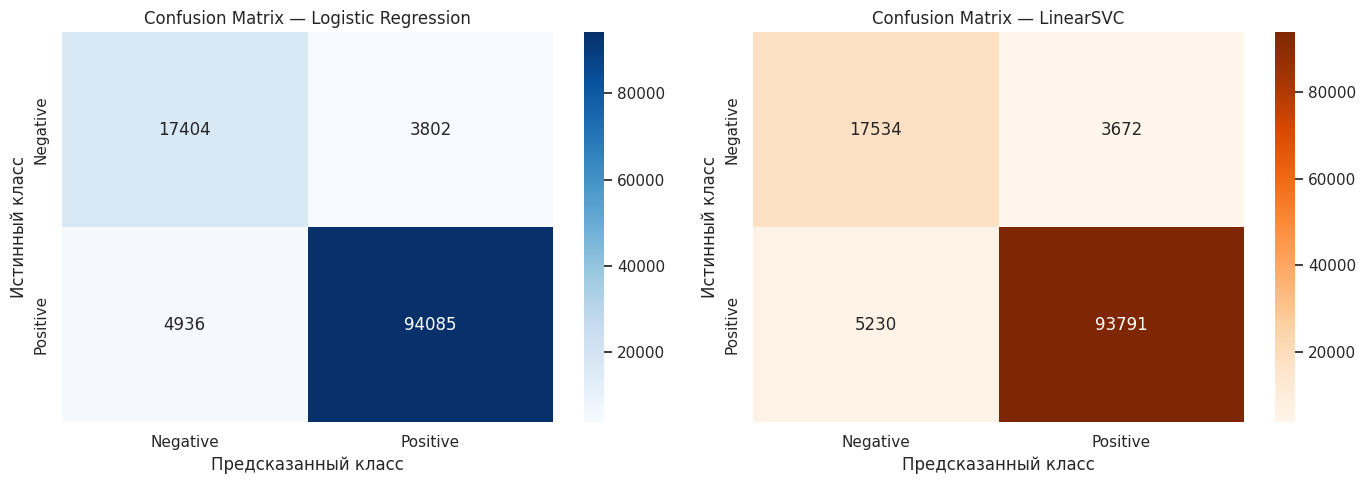

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression
cm_lr = confusion_matrix(y_test, lr_preds)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
axes[0].set_title('Confusion Matrix — Logistic Regression')
axes[0].set_xlabel('Предсказанный класс')
axes[0].set_ylabel('Истинный класс')

# LinearSVC
cm_svm = confusion_matrix(y_test, svm_preds)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
axes[1].set_title('Confusion Matrix — LinearSVC')
axes[1].set_xlabel('Предсказанный класс')
axes[1].set_ylabel('Истинный класс')

plt.tight_layout()
plt.show()

             Модель  Accuracy  Precision (macro)  Recall (macro)  F1-Score (macro)
Logistic Regression    0.9273             0.8701          0.8854            0.8775
          LinearSVC    0.9260             0.8663          0.8870            0.8761


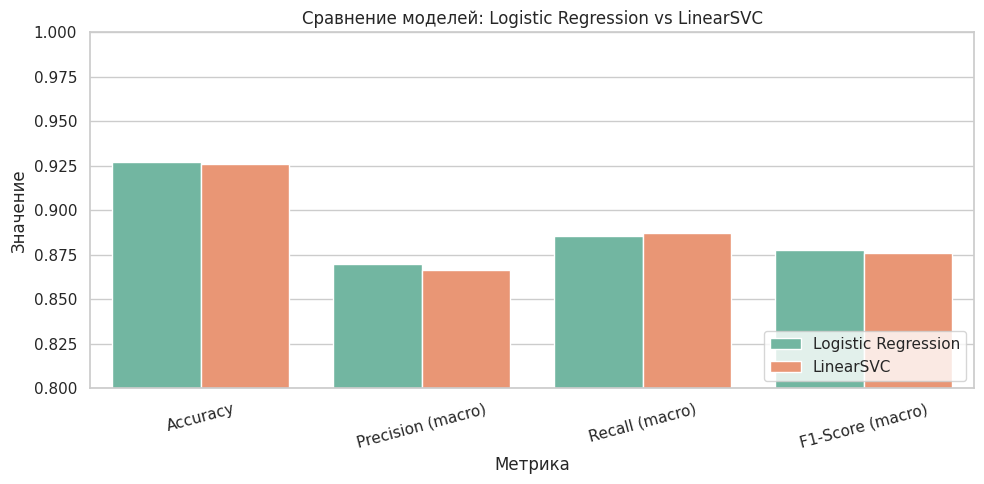

In [9]:
models_comparison = pd.DataFrame({
    'Модель': ['Logistic Regression', 'LinearSVC'],
    'Accuracy': [
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, svm_preds)
    ],
    'Precision (macro)': [
        precision_score(y_test, lr_preds, average='macro'),
        precision_score(y_test, svm_preds, average='macro')
    ],
    'Recall (macro)': [
        recall_score(y_test, lr_preds, average='macro'),
        recall_score(y_test, svm_preds, average='macro')
    ],
    'F1-Score (macro)': [
        f1_score(y_test, lr_preds, average='macro'),
        f1_score(y_test, svm_preds, average='macro')
    ]
})

models_comparison = models_comparison.round(4)
print(models_comparison.to_string(index=False))

models_melted = models_comparison.melt(id_vars='Модель', var_name='Метрика', value_name='Значение')
plt.figure(figsize=(10, 5))
sns.barplot(data=models_melted, x='Метрика', y='Значение', hue='Модель', palette='Set2')
plt.title('Сравнение моделей: Logistic Regression vs LinearSVC')
plt.ylim(0.8, 1.0)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

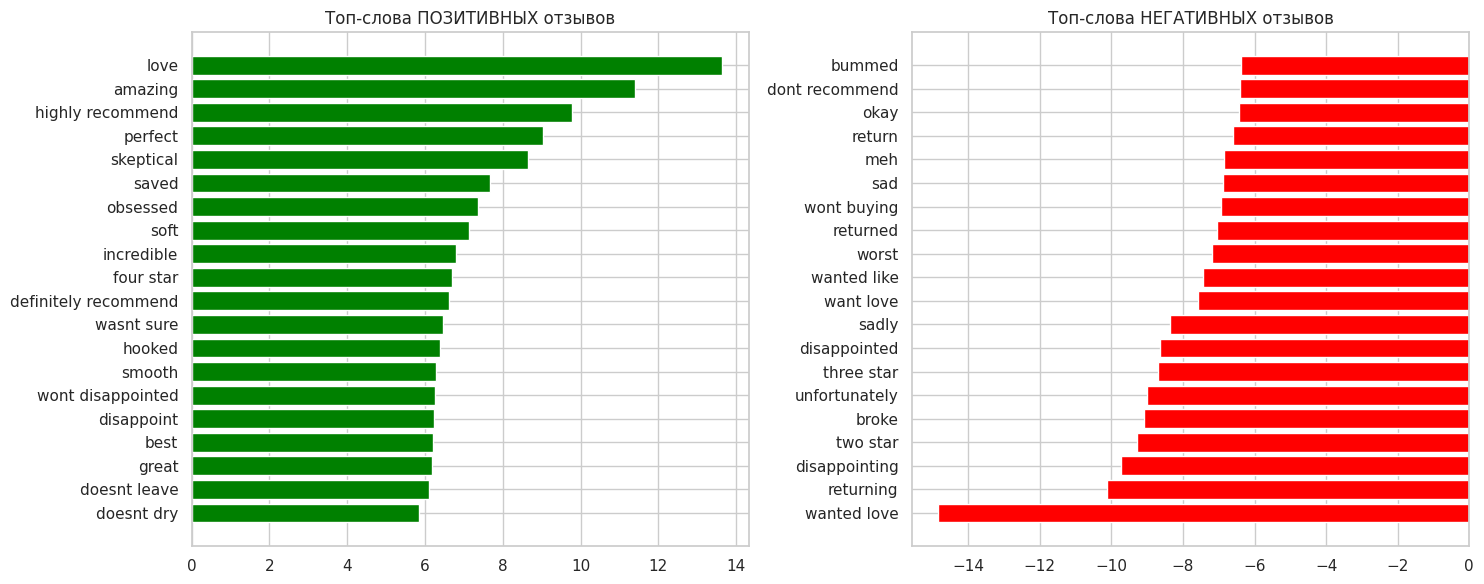

In [10]:
def plot_top_features(model, vectorizer, top_n=20):
    feature_names = vectorizer.get_feature_names_out()
    coefs = model.coef_[0]
    
    # Собираем слова и их веса
    top_pos = np.argsort(coefs)[-top_n:]
    top_neg = np.argsort(coefs)[:top_n]
    
    plt.figure(figsize=(15, 6))
    
    plt.subplot(1, 2, 1)
    plt.barh(np.array(feature_names)[top_pos], coefs[top_pos], color='green')
    plt.title('Топ-слова ПОЗИТИВНЫХ отзывов')
    
    plt.subplot(1, 2, 2)
    plt.barh(np.array(feature_names)[top_neg], coefs[top_neg], color='red')
    plt.title('Топ-слова НЕГАТИВНЫХ отзывов')
    plt.tight_layout()
    plt.show()

plot_top_features(lr_model, tfidf)

In [11]:
# векторизуем весь очищенный текст
X_all_tfidf = tfidf.transform(df['cleaned_review'])

# Получаем вероятность позитивного класса (индекс 1)
df['sentiment_probability'] = lr_model.predict_proba(X_all_tfidf)[:, 1]

brand_rating = df.groupby('brand_name').agg({
    'sentiment_probability': 'mean',
    'rating': 'mean',
    'review_text': 'count'
}).rename(columns={'review_text': 'reviews_count'})

brand_rating = brand_rating[brand_rating['reviews_count'] > 100].sort_values(by='sentiment_probability', ascending=False)

print("Топ-10 брендов по версии NLP-анализа:")
print(brand_rating.head(10))

Топ-10 брендов по версии NLP-анализа:
                           sentiment_probability    rating  reviews_count
brand_name                                                               
Dermalogica                             0.902512  4.663693          11656
Bobbi Brown                             0.882587  4.605876           3438
Dr. Brandt Skincare                     0.875968  4.579258           1186
Jack Black                              0.858370  4.681692           3594
Lancôme                                 0.857152  4.480498           5948
Evian                                   0.856598  4.562944           1549
Shiseido                                0.856025  4.586670          11238
Dr. Dennis Gross Skincare               0.850001  4.523529          10179
Rosebud Perfume Co.                     0.841716  4.554668          12018
belif                                   0.840806  4.490934          19302


In [12]:
print(brand_rating.tail(10))

                  sentiment_probability    rating  reviews_count
brand_name                                                      
Peace Out                      0.733775  4.141576           7473
La Mer                         0.725457  4.057329           2756
Sol de Janeiro                 0.721073  4.125557           1346
Summer Fridays                 0.719348  4.061267          10038
Drunk Elephant                 0.709608  4.064379          32091
Dr. Jart+                      0.704260  4.039624          11710
SK-II                          0.703584  4.082626           5894
MILK MAKEUP                    0.692811  3.980000           3000
Isle of Paradise               0.678878  3.954370           2849
The INKEY List                 0.659505  3.896220          11110


Топ-10 брендов по NPS:
               brand_name  total_reviews  promoters  detractors  NPS
              Dermalogica          11656    10996.0       660.0 88.7
              Bobbi Brown           3044     2852.0       192.0 87.4
      Dr. Brandt Skincare           1186     1106.0        80.0 86.5
             bareMinerals           3727     3471.0       256.0 86.3
Dr. Dennis Gross Skincare           7878     7336.0       542.0 86.2
                 Shiseido           9889     9147.0       742.0 85.0
                  Lancôme           5323     4890.0       433.0 83.7
                   KORRES          10384     9477.0       907.0 82.5
                innisfree           2664     2427.0       237.0 82.2
               Jack Black            854      778.0        76.0 82.2

Анти-топ-10 брендов по NPS:
      brand_name  total_reviews  promoters  detractors  NPS
       Herbivore           1494     1180.0       314.0 58.0
  Sol de Janeiro           1195      923.0       272.0 54.5
         

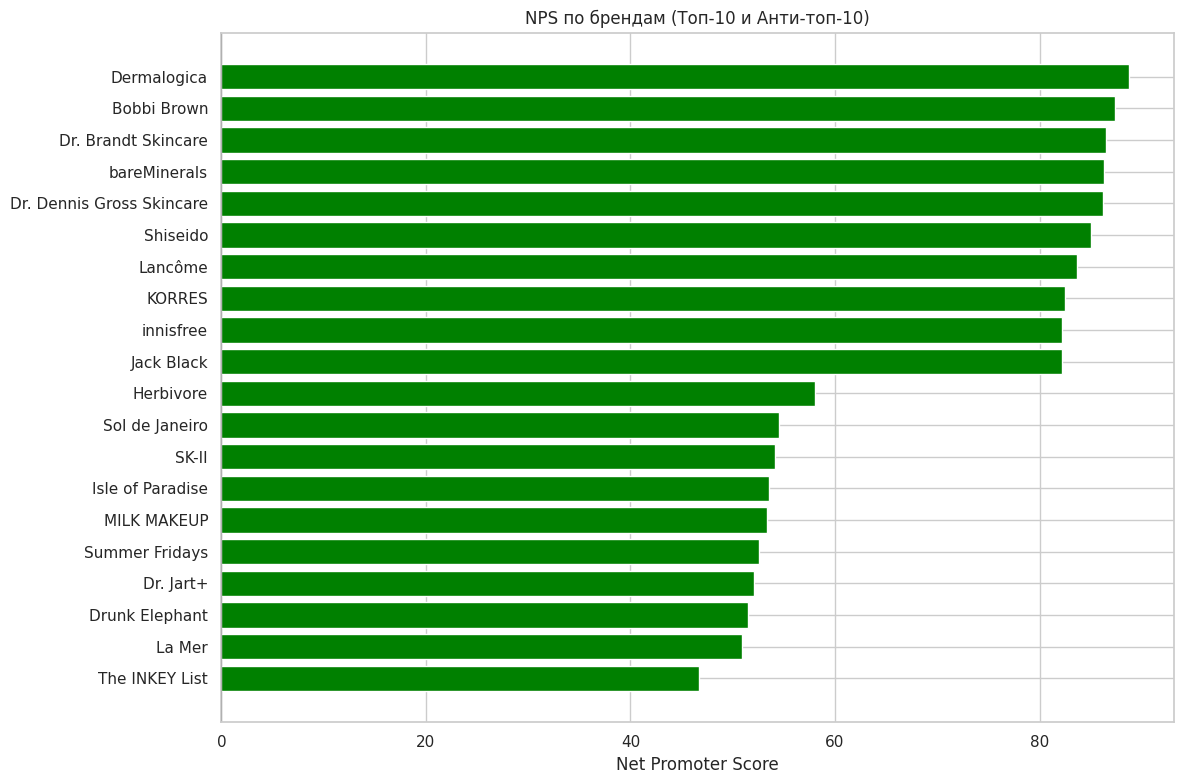

In [13]:
# NPS (Net Promoter Score) — индекс лояльности клиентов.
# Формула: NPS = (% промоутеров - % критиков) 
# Промоутеры — те, кто рекомендует продукт (is_recommended == 1)
# Критики — те, кто не рекомендует (is_recommended == 0)
# Диапазон от -100 до +100, чем выше — тем лояльнее клиенты
# Считаем по брендам, фильтруем бренды с >100 отзывами для репрезентативности
nps_data = df.dropna(subset=['is_recommended']).copy()

nps_by_brand = nps_data.groupby('brand_name').agg(
    total_reviews=('is_recommended', 'count'),
    promoters=('is_recommended', 'sum')).reset_index()


nps_by_brand['detractors'] = nps_by_brand['total_reviews'] - nps_by_brand['promoters']
nps_by_brand['NPS'] = ((nps_by_brand['promoters'] - nps_by_brand['detractors']) / nps_by_brand['total_reviews'] * 100).round(1)

nps_by_brand = nps_by_brand[nps_by_brand['total_reviews'] > 100].sort_values('NPS', ascending=False)

print("Топ-10 брендов по NPS:")
print(nps_by_brand.head(10).to_string(index=False))
print("\nАнти-топ-10 брендов по NPS:")
print(nps_by_brand.tail(10).to_string(index=False))

top_bottom = pd.concat([nps_by_brand.head(10), nps_by_brand.tail(10)])
plt.figure(figsize=(12, 8))
colors = ['green' if x > 0 else 'red' for x in top_bottom['NPS']]
plt.barh(top_bottom['brand_name'], top_bottom['NPS'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('NPS по брендам (Топ-10 и Анти-топ-10)')
plt.xlabel('Net Promoter Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Retention Rate по сегментам клиентов:
   segment  total_authors  returning_authors  Retention Rate (%)
Негативный          57635              20626               35.79
Позитивный         280840             111702               39.77


/tmp/ipykernel_55/1738840578.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=retention, x='segment', y='Retention Rate (%)', palette=['#e74c3c', '#2ecc71'])


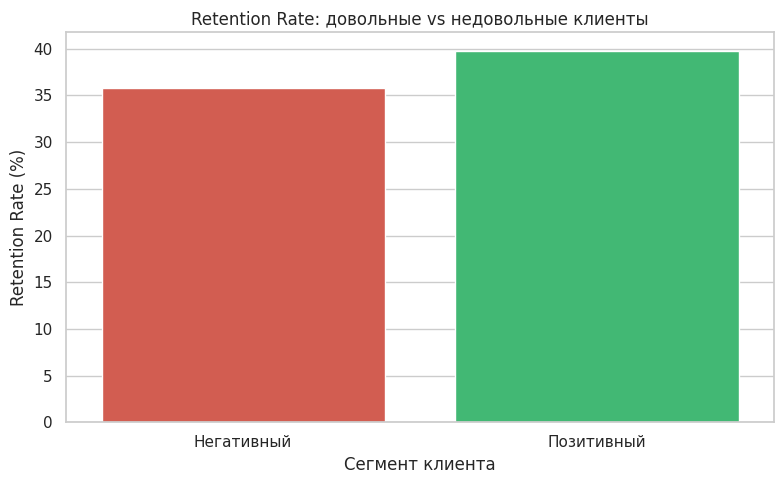

In [14]:
# Retention Rate — доля клиентов, вернувшихся за повторной покупкой.
# если автор оставил 2+ отзыва — значит, купил повторно.
# Группируем авторов по среднему sentiment на два сегмента:
# «Позитивный» (avg sentiment >= 0.5) и «Негативный» (< 0.5)
# Сравниваем долю вернувшихся в каждом сегменте.
author_stats = df.groupby('author_id').agg(
    review_count=('review_text', 'count'),
    avg_sentiment=('sentiment_probability', 'mean')
).reset_index()

author_stats['segment'] = author_stats['avg_sentiment'].apply(
    lambda x: 'Позитивный' if x >= 0.5 else 'Негативный'
)
author_stats['is_returning'] = (author_stats['review_count'] >= 2).astype(int)

retention = author_stats.groupby('segment').agg(
    total_authors=('author_id', 'count'),
    returning_authors=('is_returning', 'sum')
).reset_index()

retention['Retention Rate (%)'] = (retention['returning_authors'] / retention['total_authors'] * 100).round(2)

print("Retention Rate по сегментам клиентов:")
print(retention.to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(data=retention, x='segment', y='Retention Rate (%)', palette=['#e74c3c', '#2ecc71'])
plt.title('Retention Rate: довольные vs недовольные клиенты')
plt.ylabel('Retention Rate (%)')
plt.xlabel('Сегмент клиента')
plt.tight_layout()
plt.show()

CLV по сегментам клиентов:
   segment  avg_CLV  median_CLV  avg_purchases  total_clients
Негативный    72.78        50.0            1.6          57635
Позитивный    82.42        52.0            1.8         280840


/tmp/ipykernel_55/2055629589.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=clv_summary, x='segment', y='avg_CLV', palette=['#e74c3c', '#2ecc71'])


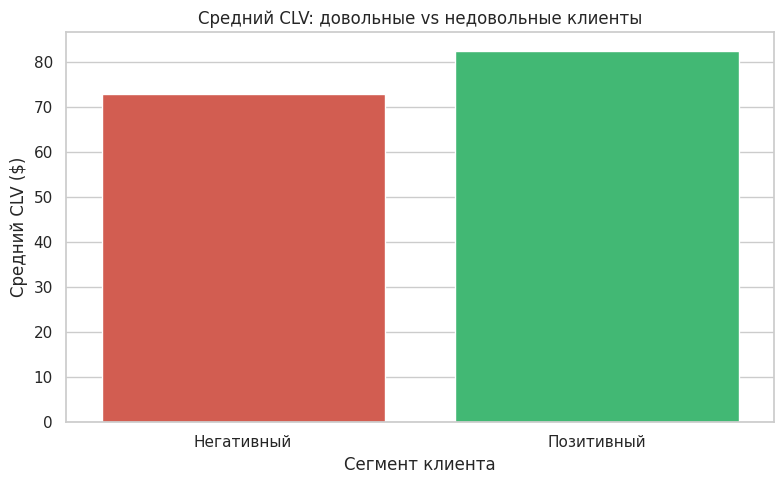

In [15]:
# CLV (Customer Lifetime Value) — пожизненная ценность клиента.
# Упрощённая формула: CLV = средняя цена покупки * кол-во уникальных продуктов.
# Группируем по author_id, считаем кол-во уникальных product_id и среднюю цену.
# Сравниваем CLV довольных и недовольных клиентов.
clv_data = df.groupby('author_id').agg(
    purchase_count=('product_id', 'nunique'),
    avg_price=('price_usd', 'mean'),
    avg_sentiment=('sentiment_probability', 'mean')
).reset_index()

clv_data['CLV'] = clv_data['avg_price'] * clv_data['purchase_count']
clv_data['segment'] = clv_data['avg_sentiment'].apply(
    lambda x: 'Позитивный' if x >= 0.5 else 'Негативный'
)

clv_summary = clv_data.groupby('segment').agg(
    avg_CLV=('CLV', 'mean'),
    median_CLV=('CLV', 'median'),
    avg_purchases=('purchase_count', 'mean'),
    total_clients=('author_id', 'count')
).round(2).reset_index()

print("CLV по сегментам клиентов:")
print(clv_summary.to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(data=clv_summary, x='segment', y='avg_CLV', palette=['#e74c3c', '#2ecc71'])
plt.title('Средний CLV: довольные vs недовольные клиенты')
plt.ylabel('Средний CLV ($)')
plt.xlabel('Сегмент клиента')
plt.tight_layout()
plt.show()

Топ-10 брендов по Brand Health Index:
               brand_name  Health_Index  total_reviews
              Dermalogica        0.9943          11656
                     goop        0.7521           6648
                 GUERLAIN        0.7269           2470
                 Shiseido        0.7084          11238
              Bobbi Brown        0.6979           3438
      Dr. Brandt Skincare        0.6774           1186
               Jack Black        0.6738           3594
                  Lancôme        0.6583           5948
Dr. Dennis Gross Skincare        0.6455          10179
                  Farmacy        0.6237          16905


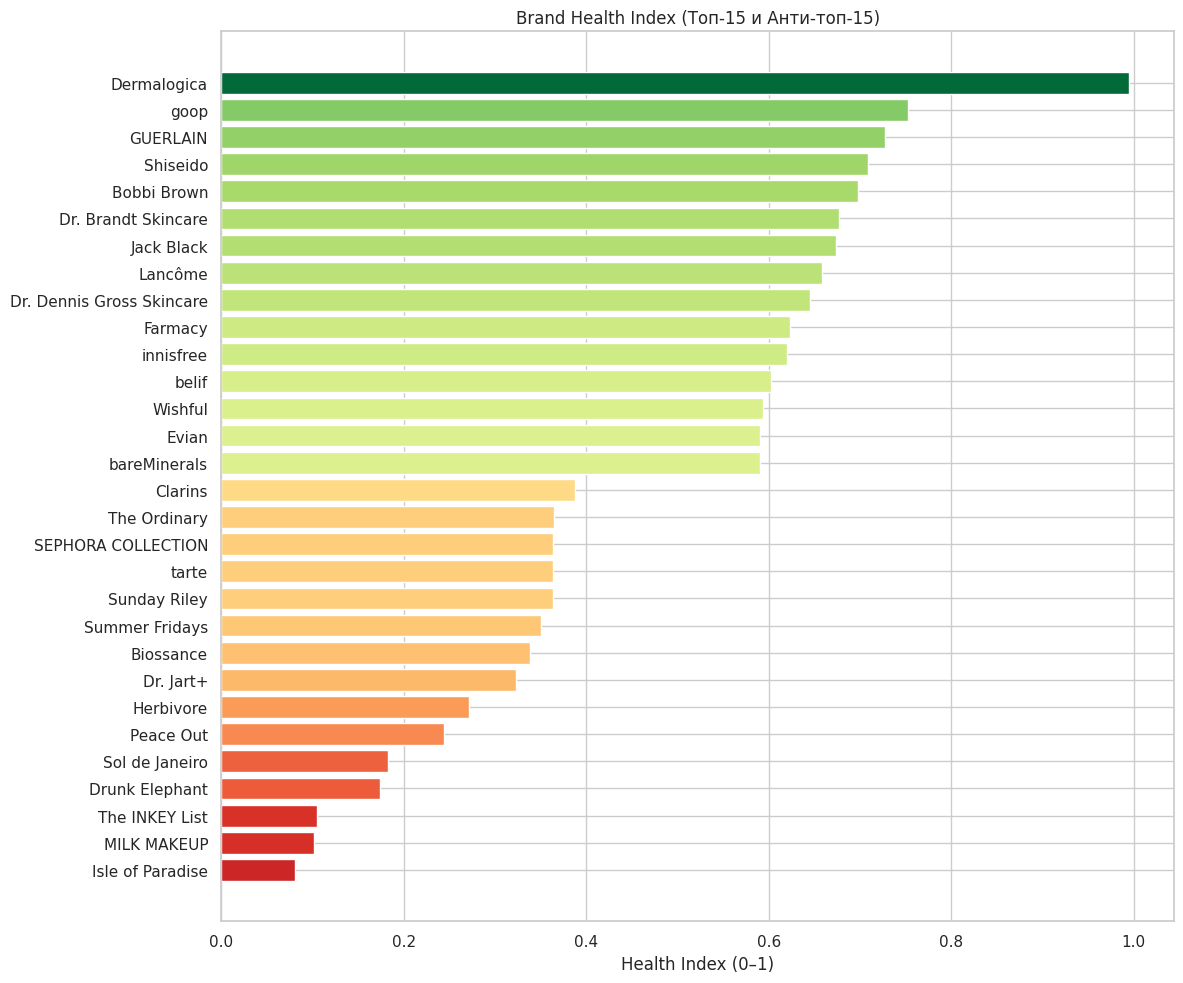

In [16]:
# Brand Health Index — композитная метрика здоровья бренда.
# Объединяет 4 компонента: sentiment score, средний рейтинг,
# долю рекомендаций (is_recommended) и retention rate.
# Каждый компонент нормализуется от 0 до 1 через MinMaxScaler.
# Итоговый индекс = среднее по четырём компонентам.
# Позволяет оценить бренд комплексно одним числом от 0 до 1.

# Собираем данные по брендам
brand_health = df.groupby('brand_name').agg(
    avg_sentiment=('sentiment_probability', 'mean'),
    avg_rating=('rating', 'mean'),
    total_reviews=('review_text', 'count'),
    recommend_rate=('is_recommended', 'mean')
).reset_index()

# Retention по брендам
brand_retention = df.groupby(['brand_name', 'author_id']).size().reset_index(name='reviews_per_author')
brand_retention['is_returning'] = (brand_retention['reviews_per_author'] >= 2).astype(int)
brand_ret_agg = brand_retention.groupby('brand_name')['is_returning'].mean().reset_index()
brand_ret_agg.columns = ['brand_name', 'retention_rate']

brand_health = brand_health.merge(brand_ret_agg, on='brand_name', how='left')
brand_health = brand_health[brand_health['total_reviews'] > 100]

# Нормализуем компоненты от 0 до 1
scaler = MinMaxScaler()
components = ['avg_sentiment', 'avg_rating', 'recommend_rate', 'retention_rate']
brand_health[components] = scaler.fit_transform(brand_health[components])

# Итоговый индекс = среднее по компонентам
brand_health['Health_Index'] = brand_health[components].mean(axis=1).round(4)
brand_health = brand_health.sort_values('Health_Index', ascending=False)

print("Топ-10 брендов по Brand Health Index:")
print(brand_health[['brand_name', 'Health_Index', 'total_reviews']].head(10).to_string(index=False))

top_bottom_bh = pd.concat([brand_health.head(15), brand_health.tail(15)])
plt.figure(figsize=(12, 10))
colors = plt.cm.RdYlGn(top_bottom_bh['Health_Index'])
plt.barh(top_bottom_bh['brand_name'], top_bottom_bh['Health_Index'], color=colors)
plt.title('Brand Health Index (Топ-15 и Анти-топ-15)')
plt.xlabel('Health Index (0–1)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Топ-10 переоценённых товаров (цена >> удовлетворённость):
                                                                product_name     brand_name  avg_price  avg_sentiment     gap
                                                 Crème de la Mer Moisturizer         La Mer     380.00       0.725457  0.5319
                                   Facial Treatment Essence (Pitera Essence)          SK-II     245.00       0.703652  0.2211
               Advanced Night Repair Synchronized Multi-Recovery Complex Duo   Estée Lauder     195.00       0.706268  0.0828
                                   Umbra Sheer Physical Daily Defense SPF 30 Drunk Elephant      34.00       0.509366  0.0822
                                                 C-Tango Vitamin C Eye Cream Drunk Elephant      64.00       0.624850 -0.0884
                                                          Oat Cleansing Balm The INKEY List      11.99       0.575843 -0.1202
Estee Lauder Advanced Night Repair Synchronized Multi-Recove

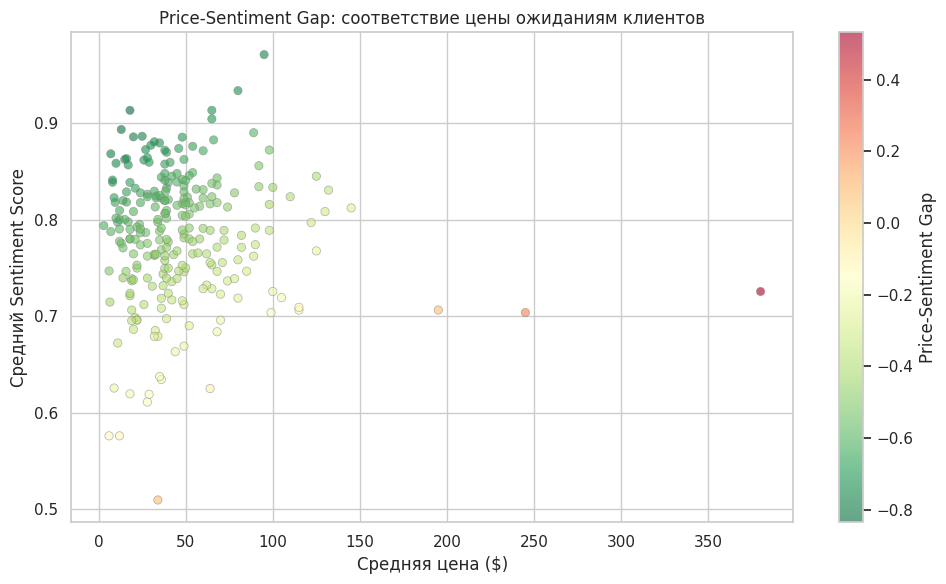

In [17]:
# Price-Sentiment Gap — метрика соответствия цены ожиданиям клиентов.
# Нормализуем цену и sentiment от 0 до 1, вычитаем: gap = цена_норм - sentiment_норм.
# gap > 0 — товар переоценён 
# gap < 0 — хорошее соотношение цена/качество 
# Считаем по продуктам, фильтруем товары с >50 отзывами.
product_gap = df.groupby(['product_name', 'brand_name']).agg(
    avg_price=('price_usd', 'mean'),
    avg_sentiment=('sentiment_probability', 'mean'),
    review_count=('review_text', 'count')
).reset_index()

product_gap = product_gap[product_gap['review_count'] > 50]

# Нормализуем
product_gap['price_norm'] = (product_gap['avg_price'] - product_gap['avg_price'].min()) / \
                            (product_gap['avg_price'].max() - product_gap['avg_price'].min())
product_gap['sentiment_norm'] = (product_gap['avg_sentiment'] - product_gap['avg_sentiment'].min()) / \
                                (product_gap['avg_sentiment'].max() - product_gap['avg_sentiment'].min())

product_gap['gap'] = (product_gap['price_norm'] - product_gap['sentiment_norm']).round(4)

print("Топ-10 переоценённых товаров (цена >> удовлетворённость):")
print(product_gap.nlargest(10, 'gap')[['product_name', 'brand_name', 'avg_price', 'avg_sentiment', 'gap']].to_string(index=False))

print("\nТоп-10 товаров с лучшим соотношением цена/качество:")
print(product_gap.nsmallest(10, 'gap')[['product_name', 'brand_name', 'avg_price', 'avg_sentiment', 'gap']].to_string(index=False))

plt.figure(figsize=(10, 6))
scatter = plt.scatter(product_gap['avg_price'], product_gap['avg_sentiment'],
                      c=product_gap['gap'], cmap='RdYlGn_r', alpha=0.6, edgecolors='gray', linewidth=0.5)
plt.colorbar(scatter, label='Price-Sentiment Gap')
plt.xlabel('Средняя цена ($)')
plt.ylabel('Средний Sentiment Score')
plt.title('Price-Sentiment Gap: соответствие цены ожиданиям клиентов')
plt.tight_layout()
plt.show()

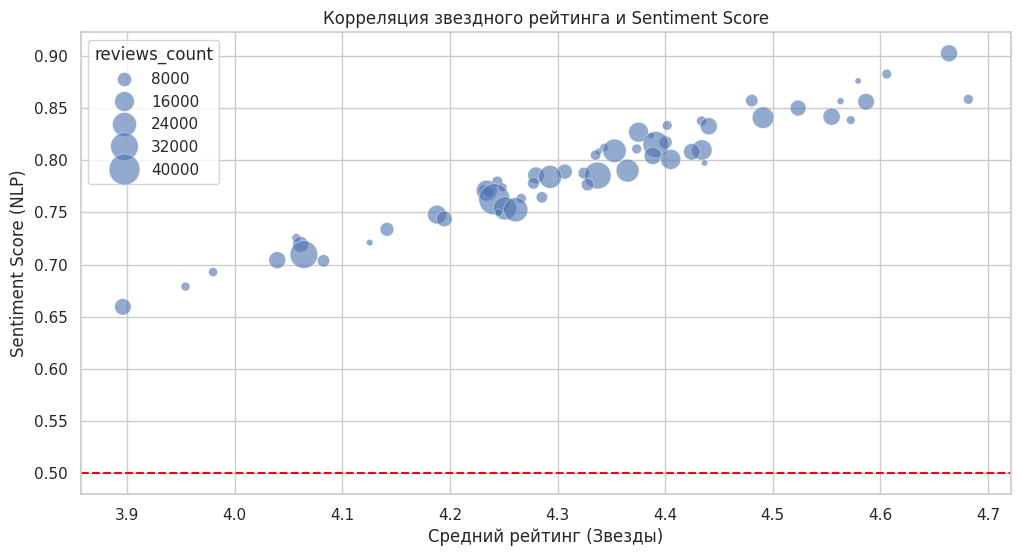

In [18]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=brand_rating, x='rating', y='sentiment_probability', size='reviews_count', alpha=0.6, sizes=(20, 500))

plt.title('Корреляция звездного рейтинга и Sentiment Score')
plt.xlabel('Средний рейтинг (Звезды)')
plt.ylabel('Sentiment Score (NLP)')
plt.axhline(0.5, color='red', linestyle='--')
plt.show()

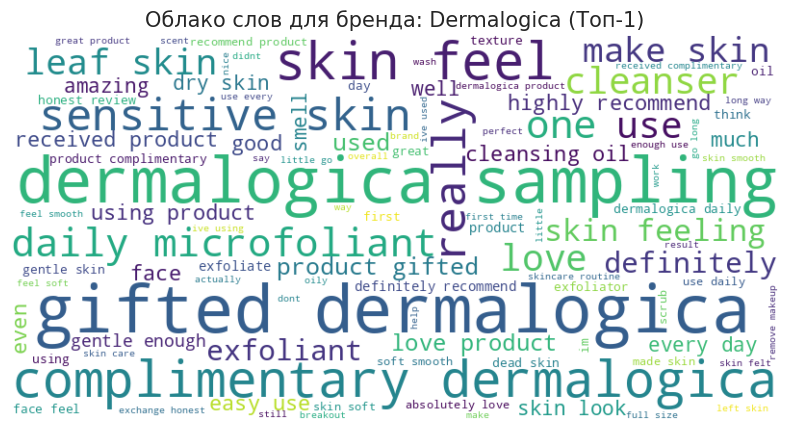

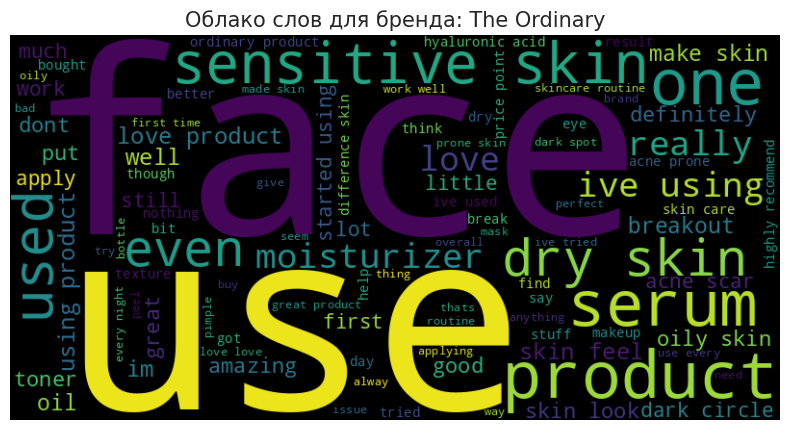

In [19]:
def generate_wordcloud(brand_name, title, color='white'):
    text = " ".join(df[df['brand_name'] == brand_name]['cleaned_review'])
    
    wordcloud = WordCloud(width=800, height=400, 
                          background_color=color, 
                          colormap='viridis',
                          max_words=100).generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Облако слов для бренда: {title}', fontsize=15)
    plt.axis('off')
    plt.show()

generate_wordcloud('Dermalogica', 'Dermalogica (Топ-1)', color='white')

generate_wordcloud('The Ordinary', 'The Ordinary', color='black')

In [20]:
df = df.merge(products_df[['product_id', 'secondary_category', 'tertiary_category']], 
              on='product_id', 
              how='left')

df = df.loc[:, ~df.columns.duplicated()]

print("Теперь в датасете есть следующие категории:")
print([col for col in df.columns if 'category' in col])

Теперь в датасете есть следующие категории:
['primary_category', 'secondary_category', 'tertiary_category']


/tmp/ipykernel_55/3357863213.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sentiment_probability', y=category_analysis.index, data=category_analysis, palette='flare')


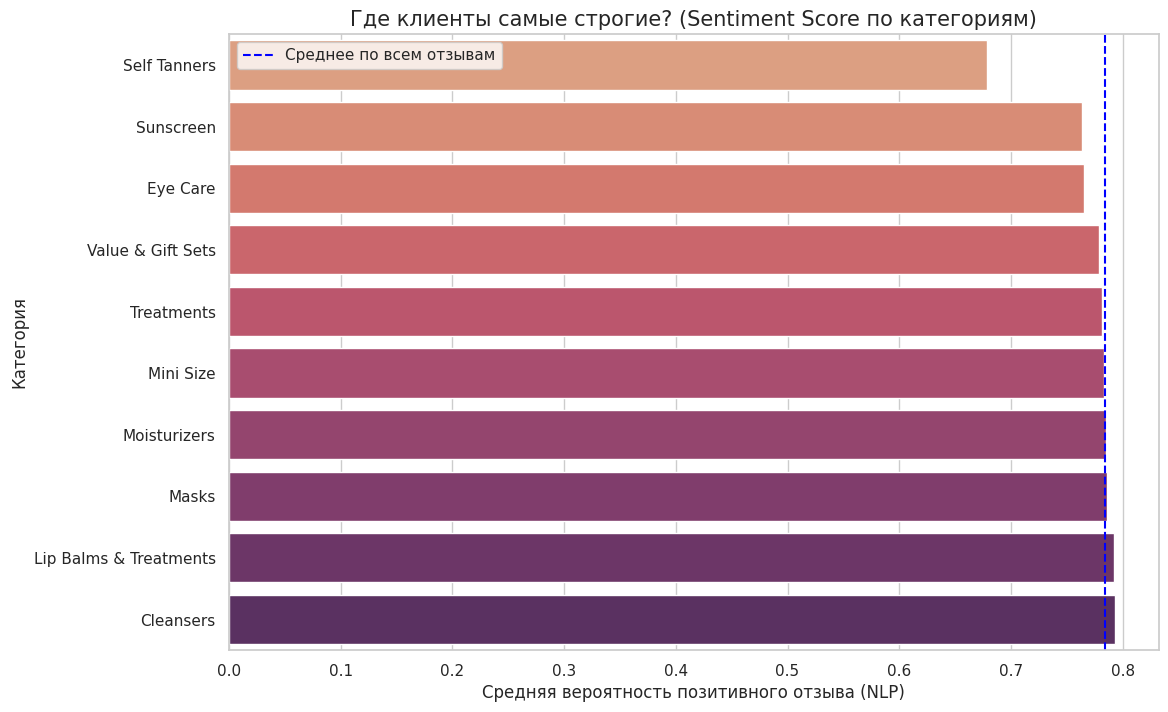

In [21]:

category_analysis = df.groupby('secondary_category').agg({
    'sentiment_probability': 'mean',
    'rating': 'mean',
    'review_text': 'count'
}).rename(columns={'review_text': 'reviews_count'})

category_analysis = category_analysis[category_analysis['reviews_count'] > 500].sort_values(by='sentiment_probability')

plt.figure(figsize=(12, 8))
sns.barplot(x='sentiment_probability', y=category_analysis.index, data=category_analysis, palette='flare')
plt.axvline(df['sentiment_probability'].mean(), color='blue', linestyle='--', label='Среднее по всем отзывам')

plt.title('Где клиенты самые строгие? (Sentiment Score по категориям)', fontsize=15)
plt.xlabel('Средняя вероятность позитивного отзыва (NLP)')
plt.ylabel('Категория')
plt.legend()
plt.show()